# Swing control optimization

- Optimize the sequence of push directions to reach a greater swing height.
- Concept: [Genetic algorithm](03-1_genetic_algorithm_concept.ipynb)


## Decision variables and fitness

- The decision variables are the left or right push directions over time.
- Each chromosome contains 16 genes: one direction per 0.5 s over an 8 s simulation.
- Gravity pulls the swing toward its lowest point, damping reduces motion, and pushing adds an external force.

> Fitness = maximum height during the simulation

- A push along the direction of motion adds energy; a push against it removes energy.
- All candidates use the same swing, initial state, force magnitude, and simulation duration. Only their push sequences differ.


## Swing motion and chromosome evolution

- The gray swing uses the best initial candidate; the teal swing uses the best candidate in the current generation.
- Each row is a chromosome, and each colored cell is a gene. Blue means a left push; orange means a right push.
- The outlined row controls the teal swing. The gold cell marks the gene active at the current playback time.
- The right panel shows an actual offspring produced by crossover and mutation. Its population row has an orange dot; mutated genes have red outlines.
- After each replay, the next generation updates both the swing and the chromosomes. The generation slider allows direct comparison between generations.


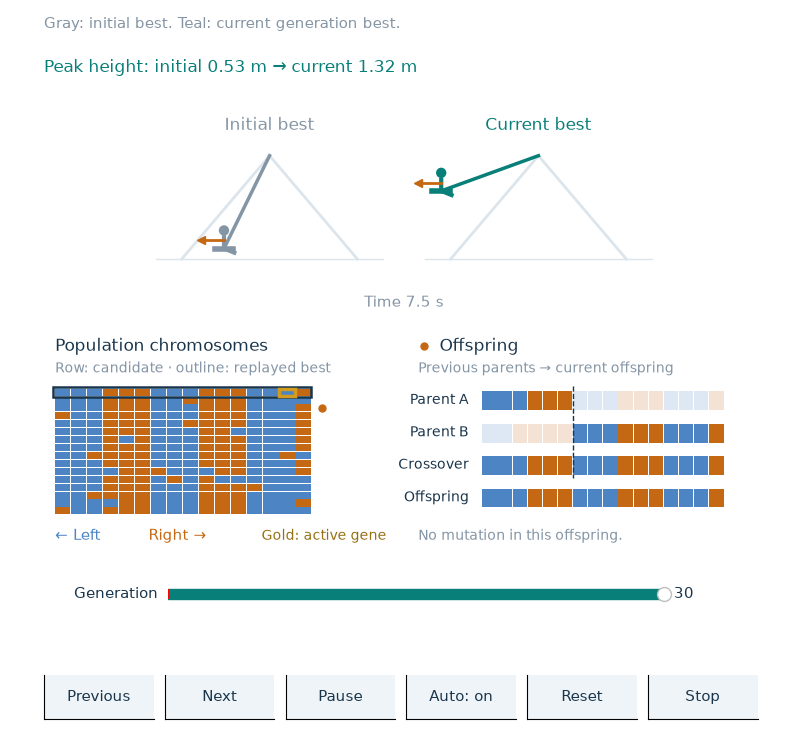

In [1]:
_optimization_inline_html = True

import os
import sys
import time
import base64
from pathlib import Path
from tempfile import gettempdir
import numpy as np
import matplotlib

STATIC = os.environ.get('OPTIMIZATION_STATIC') == '1'
BROWSER = sys.platform == 'emscripten'
INLINE_HTML = bool(globals().pop('_optimization_inline_html', False))
if not STATIC and not BROWSER and not INLINE_HTML:
    from IPython import get_ipython
    shell = get_ipython()
    if shell is not None and getattr(shell, 'kernel', None) is not None:
        shell.run_line_magic('matplotlib', 'widget')

import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.widgets import Slider, Button
from matplotlib.patches import Rectangle, Circle

# A subset of DejaVu Sans is bundled for consistent offline rendering.
FONT_DATA = '...'
_font_path = Path(gettempdir()) / 'optimization-lecture-font.ttf'
_font_bytes = base64.b64decode(FONT_DATA)
if not _font_path.exists() or _font_path.read_bytes() != _font_bytes:
    _font_path.write_bytes(_font_bytes)
font_manager.fontManager.addfont(str(_font_path))
_font_name = font_manager.FontProperties(fname=str(_font_path)).get_name()
NAVY, TEAL, GRAY = '#19354c', '#087f79', '#8495a5'
ORANGE, GOLD, RED = '#c56813', '#d39c20', '#bc3b50'
PALE = '#eef4f7'
plt.rcParams.update({
    'font.family': _font_name, 'font.size': 11, 'axes.titlesize': 12,
    'axes.titleweight': 'normal', 'axes.unicode_minus': False,
    'text.color': NAVY, 'axes.labelcolor': NAVY, 'axes.spines.top': False,
    'axes.spines.right': False, 'figure.facecolor': 'white',
    'axes.facecolor': 'white', 'savefig.facecolor': 'white', 'figure.dpi': 100,
})


class LiveView:
    """A motion comparison, one progress curve, and a small set of controls."""

    def __init__(self, subtitle, duration, last_stage, stage_label='Iteration', step_size=False):
        self.figure = plt.figure(figsize=(8, 6.6))
        self.figure.text(.055, .895, subtitle, fontsize=11, color=GRAY)
        self.status = self.figure.text(.055, .840, '', fontsize=12, color=TEAL)
        self.scene = self.figure.add_axes([.07, .465, .87, .34])
        self.progress = self.figure.add_axes([.12, .268, .79, .12])
        self.controls, self.state = {}, {}
        self.duration, self.elapsed = float(duration), 0.
        self.playing, self.automatic, self.running = True, True, False
        self.timer = None
        self.last_tick = time.monotonic()
        self.render = lambda t: None
        self.redraw = lambda: None
        self.last_stage = int(last_stage)
        self.stage_label = stage_label
        self.figure.canvas.mpl_connect('close_event', lambda event: self.stop())
        self.add_slider('stage', stage_label, 0, last_stage, 0, 1, [.21, .175, .62, .025], '%0.0f')
        if step_size:
            self.add_slider('alpha', 'Step size', .05, 2.3, .35, .05, [.21, .120, .62, .025], '%0.2f')
        actions = [('back', 'Previous', lambda _: self.manual_step(-1)),
                   ('next', 'Next', lambda _: self.manual_step(1)),
                   ('play', 'Pause', self.toggle_play),
                   ('auto', 'Auto: on', self.toggle_auto),
                   ('reset', 'Reset', lambda _: self.reset_all()),
                   ('stop', 'Stop', lambda _: self.stop())]
        for i, (name, label, callback) in enumerate(actions):
            button = Button(self.figure.add_axes([.055 + .151*i, .031, .137, .055]), label,
                            color=PALE, hovercolor='#d4e8e4')
            button.label.set_fontsize(10.5)
            button.on_clicked(callback)
            self.controls[name] = button
        self.controls['stage'].on_changed(self.choose_stage)
        if step_size:
            self.controls['alpha'].on_changed(self.change_step_size)
        self.figure._live_view = self

    def compact_header(self):
        width, height = self.figure.get_size_inches()
        new_height = height - .56
        scale = height / new_height
        for ax in self.figure.axes:
            x, y, w, h = ax.get_position().bounds
            ax.set_position([x, y*scale, w, h*scale])
        for text in self.figure.texts:
            x, y = text.get_position()
            text.set_position((x, y*scale))
        self.figure.set_size_inches(width, new_height)

    def add_slider(self, name, label, low, high, initial, step, rect, valfmt):
        slider = Slider(self.figure.add_axes(rect), label, low, high, valinit=initial,
                        valstep=step, valfmt=valfmt, color=TEAL)
        slider.label.set_fontsize(11)
        slider.valtext.set_fontsize(11)
        self.controls[name] = slider

    def values(self, **values):
        for name, value in values.items():
            slider = self.controls[name]
            old_events, old_draw = slider.eventson, slider.drawon
            slider.eventson = slider.drawon = False
            slider.set_val(value)
            slider.eventson, slider.drawon = old_events, old_draw

    def sync(self):
        self.controls['play'].label.set_text('Pause' if self.playing else 'Play')
        self.controls['auto'].label.set_text('Auto: on' if self.automatic else 'Auto: off')
        self.figure.canvas.draw_idle()

    def choose_stage(self, _):
        self.automatic = False
        self.redraw()
        self.sync()

    def change_step_size(self, _):
        self.values(stage=0)
        self.automatic, self.playing = True, True
        self.redraw()
        self.sync()

    def advance(self, direction):
        old = int(self.controls['stage'].val)
        new = int(np.clip(old + direction, 0, self.last_stage))
        if old == new:
            return False
        self.values(stage=new)
        self.redraw()
        return True

    def manual_step(self, direction):
        self.automatic = False
        self.advance(direction)
        self.sync()

    def clear(self):
        self.scene.clear()
        self.progress.clear()

    def history(self, values, title, last_stage):
        values = np.asarray(values, dtype=float)
        ax = self.progress
        ax.plot(np.arange(len(values)), values, color=TEAL, lw=2.5)
        ax.plot(len(values)-1, values[-1], 'o', color=TEAL, ms=6)
        ax.axhline(values[0], color=GRAY, ls='--', lw=1, alpha=.7)
        ax.set_title(title, loc='left', pad=9)
        ax.set_xlim(-.5, last_stage+.5)
        top = max(1e-3, float(values.max()))
        ax.set_ylim(0, top*1.25)
        ax.set_xticks([0, last_stage])
        ax.set_yticks([0, top])
        ax.set_yticklabels(['0', f'{top:.2g}'])
        ax.tick_params(labelsize=10)
        ax.spines[['top', 'right']].set_visible(False)
        ax.spines[['left', 'bottom']].set_color('#ccd7df')

    def set_motion(self, render):
        self.render = render
        self.elapsed = 0.
        self.last_tick = time.monotonic()
        self.frame(0.)

    def frame(self, seconds):
        self.render(float(np.clip(seconds, 0, self.duration)))
        self.figure.canvas.draw_idle()

    def toggle_play(self, _=None):
        if not self.playing and self.elapsed >= self.duration:
            self.elapsed = 0.
        self.playing = not self.playing
        self.last_tick = time.monotonic()
        self.sync()

    def toggle_auto(self, _=None):
        self.automatic = not self.automatic
        if self.automatic:
            if self.elapsed >= self.duration:
                self.elapsed = 0.
            self.playing = True
        self.last_tick = time.monotonic()
        self.sync()

    def reset_all(self):
        self.automatic, self.playing = True, True
        self.values(stage=0, **({'alpha': .35} if 'alpha' in self.controls else {}))
        self.redraw()
        self.sync()

    def tick(self, now=None):
        now = time.monotonic() if now is None else now
        delta = max(0., now-self.last_tick)
        self.last_tick = now
        if not self.running or not self.playing:
            return
        self.elapsed += delta
        if self.elapsed > self.duration+.7:
            if self.automatic and self.advance(1):
                self.elapsed = 0.
            else:
                self.elapsed = self.duration
                self.playing = self.automatic = False
                self.sync()
        self.frame(self.elapsed)

    def start(self):
        if STATIC:
            self.values(stage=self.last_stage)
            self.redraw()
            self.elapsed = getattr(self, 'preview_time', .7*self.duration)
            self.frame(self.elapsed)
            from io import BytesIO
            from IPython.display import Image, display
            preview = BytesIO()
            self.figure.savefig(preview, format='png', dpi=100, bbox_inches=None)
            display(Image(data=preview.getvalue(), width=800))
            plt.close(self.figure)
            return
        self.running = True
        self.last_tick = time.monotonic()
        self.controls['stop'].label.set_text('Stop')
        if BROWSER:
            plt.show()
            try:
                while self.running and plt.fignum_exists(self.figure.number):
                    self.tick()
                    plt.pause(1/30)
            finally:
                self.stop()
        else:
            if self.timer is not None:
                self.timer.stop()
            self.timer = self.figure.canvas.new_timer(interval=33)
            self.timer.add_callback(self.tick)
            self.timer.start()
            plt.show()

    def stop(self):
        self.running = self.playing = False
        if self.timer is not None:
            self.timer.stop()
        self.controls['stop'].label.set_text('Stopped')
        self.sync()

    def close(self):
        self.stop()
        plt.close(self.figure)


SWING_LENGTH = 2.
SWING_DT = .02
SWING_DURATION = 8.
GENES = 16
GENE_TIME = .5
SWING_FORCE = .65
SWING_DAMPING = .12
GA_SIZE = 16
GA_GENERATIONS = 30


def simulate_swings(population):
    """Fixed-step semi-implicit Euler; identical initial state for every policy."""
    population = np.atleast_2d(np.asarray(population, dtype=int))
    n = round(SWING_DURATION / SWING_DT)
    times = np.arange(n + 1) * SWING_DT
    theta = np.empty((n + 1, len(population)))
    omega = np.zeros_like(theta)
    theta[0] = .08
    actions = np.empty((n, len(population)))
    for k in range(n):
        gene = min(k // round(GENE_TIME / SWING_DT), GENES - 1)
        actions[k] = 2 * population[:, gene] - 1
        acceleration = (-9.81 / SWING_LENGTH * np.sin(theta[k])
                        - SWING_DAMPING * omega[k] + SWING_FORCE * actions[k])
        omega[k + 1] = omega[k] + SWING_DT * acceleration
        theta[k + 1] = theta[k] + SWING_DT * omega[k + 1]
    height = SWING_LENGTH * (1 - np.cos(theta))
    return dict(t=times, theta=theta, omega=omega, height=height,
                actions=actions, fitness=height.max(axis=0))


def run_ga(seed=8, mutation_rate=.08, generations=GA_GENERATIONS):
    rng = np.random.default_rng(seed)
    population = rng.integers(0, 2, (GA_SIZE, GENES))
    populations, scores, transitions = [], [], []
    for generation in range(generations + 1):
        fitness = simulate_swings(population)["fitness"]
        populations.append(population.copy())
        scores.append(fitness.copy())
        if generation == generations:
            break
        elite_idx = int(np.argmax(fitness))
        children = [population[elite_idx].copy()]
        traces = []
        for _ in range(GA_SIZE - 1):
            tournaments = [rng.choice(GA_SIZE, 3, replace=False) for _ in range(2)]
            parents = tuple(int(ids[np.argmax(fitness[ids])]) for ids in tournaments)
            cut = int(rng.integers(1, GENES))
            crossed = np.r_[population[parents[0], :cut], population[parents[1], cut:]]
            flips = rng.random(GENES) < mutation_rate
            child = crossed.copy()
            child[flips] = 1 - child[flips]
            traces.append(dict(parents=parents, tournaments=tournaments, cut=cut,
                               crossed=crossed.copy(), flips=flips.copy(), child=child.copy()))
            children.append(child)
        transitions.append(dict(elite_idx=elite_idx, children=traces))
        population = np.array(children)
    return dict(populations=populations, scores=scores, transitions=transitions)


def draw_ga_genes(view, history, generation):
    """Draw actual chromosomes and one recorded parent-to-child transition."""
    ax = view.progress
    ax.set(xlim=(0, 800), ylim=(240, 0))
    ax.axis('off')
    population = history['populations'][generation]
    best = int(np.argmax(history['scores'][generation]))
    blue = '#4c84c4'
    ax.text(8, 12, 'Population chromosomes', fontsize=12)
    ax.text(8, 36, 'Row: candidate · outline: replayed best', fontsize=10, color=GRAY)
    left, top, cw, ch = 8, 54, 18, 8.8
    for row, chromosome in enumerate(population):
        for col, bit in enumerate(chromosome):
            ax.add_patch(Rectangle((left+col*cw, top+row*ch), cw-1, ch-1,
                                   fc=ORANGE if bit else blue, ec='none'))
    ax.add_patch(Rectangle((left-2, top+best*ch-1.5), GENES*cw+2, ch+2,
                           fill=False, ec=NAVY, lw=1.8))
    cursor = Rectangle((left, top+best*ch), cw-1, ch-1, fill=False, ec=GOLD, lw=2.5)
    ax.add_patch(cursor)
    ax.text(8, 222, '← Left', color=blue, fontsize=11)
    ax.text(113, 222, 'Right →', color=ORANGE, fontsize=11)
    ax.text(240, 222, 'Gold: active gene', color='#967014', fontsize=10)
    display = dict(population=population.copy(), best=best, cursor=cursor)
    if generation == 0:
        ax.text(416, 12, 'Initial population', fontsize=12)
        ax.text(416, 70, 'Start with random push sequences.', fontsize=11)
        ax.text(416, 98, 'Replay the best initial candidate.', fontsize=11)
        ax.text(416, 145, 'Best', fontsize=10, ha='right', va='center')
        for col, bit in enumerate(population[best]):
            ax.add_patch(Rectangle((430+col*21, 133), 20, 24,
                                   fc=ORANGE if bit else blue, ec='none'))
    else:
        # The best newly made child; row zero is the unchanged elite.
        child_index = 1 + int(np.argmax(history['scores'][generation][1:]))
        trace = history['transitions'][generation-1]['children'][child_index-1]
        parents = history['populations'][generation-1][list(trace['parents'])]
        ax.plot(left+GENES*cw+12, top+(child_index+.5)*ch, 'o', color=ORANGE, ms=5)
        ax.plot(423, 7, 'o', color=ORANGE, ms=5)
        ax.text(440, 12, 'Offspring', fontsize=12)
        ax.text(416, 36, 'Previous parents → current offspring', fontsize=10, color=GRAY)
        rows = [parents[0], parents[1], trace['crossed'], trace['child']]
        x, cell_width = 488, 17
        for row, (label, chromosome) in enumerate(zip(['Parent A', 'Parent B', 'Crossover', 'Offspring'], rows)):
            y = 57 + 36*row
            ax.text(473, y+10, label, fontsize=10, ha='right', va='center')
            for col, bit in enumerate(chromosome):
                kept = row > 1 or (row == 0 and col < trace['cut']) or (row == 1 and col >= trace['cut'])
                ax.add_patch(Rectangle((x+col*cell_width, y), cell_width-1, 21,
                                       fc=ORANGE if bit else blue, ec='none', alpha=1 if kept else .18))
                if row == 3 and trace['flips'][col]:
                    ax.add_patch(Rectangle((x+col*cell_width-.5, y-.5), cell_width, 22,
                                           fill=False, ec=RED, lw=2))
        cut = x+trace['cut']*cell_width-.5
        ax.plot([cut, cut], [51, 153], color=NAVY, ls='--', lw=1)
        caption = 'Red outline: mutated genes' if np.any(trace['flips']) else 'No mutation in this offspring.'
        ax.text(416, 222, caption, color=RED if np.any(trace['flips']) else GRAY, fontsize=10)
        display.update(child_index=child_index, parents=parents.copy(), trace=trace)
    view.state['genes'] = display

    def mark_gene(t):
        col = min(GENES-1, int(t/GENE_TIME))
        cursor.set_x(left+col*cw)
        cursor.set_visible(t < SWING_DURATION)
        view.state['active_gene'] = col
    return mark_gene


def show_ga_explorer():
    view = LiveView('Gray: initial best. Teal: current generation best.', SWING_DURATION,
                    GA_GENERATIONS, stage_label='Generation')
    view.figure.set_size_inches(8, 8)
    view.scene.set_position([.07, .535, .87, .265])
    view.progress.set_position([.06, .235, .89, .27])
    view.compact_header()
    history = run_ga(seed=8, mutation_rate=.08)
    def redraw():
        generation = int(view.controls['stage'].val)
        first = history['populations'][0][np.argmax(history['scores'][0])]
        current = history['populations'][generation][np.argmax(history['scores'][generation])]
        trial = simulate_swings(np.array([first, current]))
        scores = np.array([s.max() for s in history['scores']])
        view.state.update(history=history, stage=generation, trial=trial, candidates=np.array([first, current]))
        view.clear()
        view.status.set_text(f'Peak height: initial {scores[0]:.2f} m → current {scores[generation]:.2f} m')
        ax = view.scene
        ax.set(xlim=(-5.2, 5.2), ylim=(-.3, 3.8), aspect='equal')
        ax.axis('off')
        rods, seats, heads, bodies, pushes = [], [], [], [], []
        centers, pivot = [-2.6, 2.6], 2.8
        for center, color, label in zip(centers, [GRAY, TEAL], ['Initial best', 'Current best']):
            ax.plot([center-1.7, center, center+1.7], [.8, pivot, .8], color='#dce5ec', lw=2)
            ax.plot([center-2.2, center+2.2], [.8, .8], color='#dce5ec', lw=1)
            ax.text(center, 3.3, label, ha='center', color=color, fontsize=12)
            rod, = ax.plot([], [], color=color, lw=2.5)
            seat, = ax.plot([], [], color=color, lw=4)
            head = Circle((center, 1.2), .10, fc=color)
            ax.add_patch(head)
            body, = ax.plot([], [], color=color, lw=3)
            push, = ax.plot([], [], color=ORANGE, lw=2, marker='>', markevery=[-1], ms=6)
            rods.append(rod); seats.append(seat); heads.append(head); bodies.append(body); pushes.append(push)
        clock = ax.text(0, -.12, '', ha='center', fontsize=11, color=GRAY)
        mark_gene = draw_ga_genes(view, history, generation)
        def frame(t):
            sample = min(int(t/SWING_DT), len(trial['actions'])-1)
            for j, center in enumerate(centers):
                angle = np.interp(t, trial['t'], trial['theta'][:, j])
                x, y = center+SWING_LENGTH*np.sin(angle), pivot-SWING_LENGTH*np.cos(angle)
                rods[j].set_data([center, x], [pivot, y])
                seats[j].set_data([x-.17, x+.17], [y, y])
                heads[j].center = (x, y+.35)
                bodies[j].set_data([x, x, x+.2], [y+.22, y, y-.08])
                direction = trial['actions'][sample, j] if t < SWING_DURATION else 0
                pushes[j].set_data([x, x+direction*.45], [y+.16, y+.16])
                pushes[j].set_marker('>' if direction > 0 else '<' if direction < 0 else '')
            clock.set_text(f'Time {t:.1f} s')
            mark_gene(t)
        view.preview_time = float(trial['t'][np.argmax(trial['height'][:, 1])])
        view.set_motion(frame)
    view.redraw = redraw
    redraw()
    return view


def ga_replay_data(seed=8, mutation_rate=.08):
    """Export the actual GA history and its trajectories for offline replay."""
    import base64

    history = run_ga(seed=seed, mutation_rate=mutation_rate)
    chromosomes, indices = [], {}

    def register(bits):
        key = tuple(map(int, bits))
        if key not in indices:
            indices[key] = len(chromosomes)
            chromosomes.append(list(key))
        return indices[key]

    populations = [[register(bits) for bits in group] for group in history["populations"]]
    transitions = []
    for step in history["transitions"]:
        children = [dict(parents=list(child["parents"]), cut=child["cut"],
                         crossed=register(child["crossed"]), child=register(child["child"]),
                         flips=child["flips"].tolist()) for child in step["children"]]
        transitions.append(dict(elite=step["elite_idx"], children=children))
    trial = simulate_swings(chromosomes)
    angles = np.asarray(trial["theta"].T, dtype="<f4")
    return dict(seed=seed, mutation=mutation_rate, length=SWING_LENGTH,
                dt=SWING_DT, duration=SWING_DURATION, gene_time=GENE_TIME,
                samples=len(trial["t"]), chromosomes=chromosomes,
                populations=populations, scores=[s.tolist() for s in history["scores"]],
                transitions=transitions, fitness=trial["fitness"].tolist(),
                theta=base64.b64encode(angles.tobytes()).decode("ascii"))


class SwingHTMLView:
    """An inline canvas player with no widget manager or external scripts."""

    def __init__(self, seed=8, mutation_rate=.08):
        import json
        import uuid

        self.data = ga_replay_data(seed, mutation_rate)
        self.element_id = "ga-" + uuid.uuid4().hex
        self.html = (GA_REPLAY_HTML.replace("__GA_ID__", self.element_id)
                     .replace("__GA_DATA__", json.dumps(self.data, separators=(",", ":")))
                     .replace("__GA_FONT__", FONT_DATA))
        self.running = False

    def start(self):
        from IPython.display import HTML, display
        display(HTML(self.html))
        self.running = True

    def close(self):
        # The player cancels its animation when its output is removed or replaced.
        self.running = False


def show_ga_html(seed=8, mutation_rate=.08):
    return SwingHTMLView(seed=seed, mutation_rate=mutation_rate)


GA_REPLAY_HTML = r'''
<div id="__GA_ID__" class="ga-simple">
<style>
@font-face{font-family:OptimizationSans;src:url(data:font/ttf;base64,__GA_FONT__) format('truetype')}
#__GA_ID__{max-width:800px;background:white;color:#19354c;padding:18px;box-sizing:border-box;font:17px/1.5 OptimizationSans,sans-serif}
#__GA_ID__ *{box-sizing:border-box}#__GA_ID__ p{margin:6px 0 12px}
#__GA_ID__ .ga-hint{color:#718596;font-size:16px}#__GA_ID__ .ga-score{color:#087f79;font-size:18px}
#__GA_ID__ canvas{display:block;width:100%;height:auto}#__GA_ID__ .ga-stage{display:flex;align-items:center;gap:14px;margin:20px 0}
#__GA_ID__ input{flex:1;min-width:80px;accent-color:#087f79}#__GA_ID__ output{min-width:2ch;font-variant-numeric:tabular-nums}
#__GA_ID__ .ga-buttons{display:flex;flex-wrap:wrap;gap:8px}#__GA_ID__ button{flex:1;min-width:96px;white-space:nowrap;padding:9px 8px;border:1px solid #cddce3;border-radius:6px;color:#19354c;background:#eef4f7;font:inherit;cursor:pointer}
#__GA_ID__ button:disabled{opacity:.45;cursor:default}
#__GA_ID__ .ga-genetics{display:flex;gap:20px;margin-top:12px;align-items:flex-start}
#__GA_ID__ .ga-genetics canvas{width:calc(50% - 10px);min-width:0}
@media(max-width:620px){#__GA_ID__ .ga-genetics{flex-direction:column;gap:16px}#__GA_ID__ .ga-genetics canvas{width:100%}}
</style>
<p class="ga-hint">Gray: initial best. Teal: current generation best.</p>
<p class="ga-score" data-role="score" aria-live="polite"></p>
<canvas data-plot="motion" width="800" height="285" aria-label="Swing motion of the initial and current best candidates"></canvas>
<div class="ga-genetics">
<canvas data-plot="population" width="380" height="255" aria-label="Actual chromosomes by generation; blue is left, orange is right"></canvas>
<canvas data-plot="lineage" width="400" height="255" aria-label="Actual offspring produced by crossover and mutation"></canvas>
</div>
<label class="ga-stage">Generation <input data-control="generation" type="range" min="0" max="30" step="1" value="0"><output data-value="generation">0</output></label>
<div class="ga-buttons">
<button data-action="previous">Previous</button><button data-action="next">Next</button><button data-action="play">Pause</button><button data-action="auto">Auto: on</button><button data-action="reset">Reset</button><button data-action="stop">Stop</button>
</div>
</div>
<script>
(() => {
  function findOutput(scope){
    const found=scope.querySelector('#__GA_ID__');if(found)return found;
    for(const element of scope.querySelectorAll('*')){
      if(element.shadowRoot){const found=findOutput(element.shadowRoot);if(found)return found;}
    }
    return null;
  }
  const root=findOutput(document);if(!root)return;
  const data=__GA_DATA__,bytes=Uint8Array.from(atob(data.theta),x=>x.charCodeAt(0)),angles=new DataView(bytes.buffer);
  const C={navy:'#19354c',teal:'#087f79',gray:'#8495a5',orange:'#c56813',blue:'#4c84c4',red:'#bc3b50',gold:'#d39c20',line:'#dce5ec'};
  const stage=root.querySelector('[data-control=generation]');
  const buttons=Object.fromEntries([...root.querySelectorAll('[data-action]')].map(e=>[e.dataset.action,e]));
  const plots=Object.fromEntries([...root.querySelectorAll('canvas')].map(e=>[e.dataset.plot,e]));
  const state={generation:0,t:0,playing:true,automatic:true,stopped:false};
  const last=data.populations.length-1;stage.max=last;
  const best=g=>data.scores[g].indexOf(Math.max(...data.scores[g]));
  const peaks=data.scores.map(a=>Math.max(...a));
  let pair,animation,previous=performance.now();
  function angle(id,t){
    const f=Math.min(data.samples-1,Math.max(0,t/data.dt)),k=Math.floor(f),a=f-k;
    const read=j=>angles.getFloat32((id*data.samples+j)*4,true);
    return read(k)*(1-a)+read(Math.min(k+1,data.samples-1))*a;
  }
  const height=(id,t)=>data.length*(1-Math.cos(angle(id,t)));
  function line(ctx,points,color,width=2){
    ctx.strokeStyle=color;ctx.lineWidth=width;ctx.beginPath();
    points.forEach(([x,y],i)=>i?ctx.lineTo(x,y):ctx.moveTo(x,y));ctx.stroke();
  }
  function context(name){
    const canvas=plots[name],ctx=canvas.getContext('2d');ctx.clearRect(0,0,canvas.width,canvas.height);
    ctx.font='18px OptimizationSans, sans-serif';ctx.textAlign='left';return ctx;
  }
  function drawMotion(){
    const ctx=context('motion'),t=Math.min(state.t,data.duration);
    pair.forEach((id,i)=>{
      const center=205+i*390,pivot=67,length=153,a=angle(id,t),color=i?C.teal:C.gray;
      const sx=center+length*Math.sin(a),sy=pivot+length*Math.cos(a);
      ctx.fillStyle=color;ctx.textAlign='center';ctx.fillText(i?'Current best':'Initial best',center,29);
      line(ctx,[[center-118,222],[center,pivot],[center+118,222]],C.line,3);
      line(ctx,[[center-175,224],[center+175,224]],C.line,1);
      line(ctx,[[center,pivot],[sx,sy]],color,3);
      line(ctx,[[sx-13,sy],[sx+13,sy]],color,5);
      line(ctx,[[sx,sy-6],[sx,sy-23]],color,4);
      ctx.fillStyle=color;ctx.beginPath();ctx.arc(sx,sy-32,8,0,Math.PI*2);ctx.fill();
      line(ctx,[[sx,sy-5],[sx+13,sy+9],[sx+20,sy+8]],color,3);
      if(t<data.duration){
        const gene=Math.min(data.chromosomes[id].length-1,Math.floor(t/data.gene_time));
        const action=2*data.chromosomes[id][gene]-1,ex=sx+action*40;
        line(ctx,[[sx,sy-15],[ex,sy-15]],C.orange,3);
        line(ctx,[[ex-action*8,sy-20],[ex,sy-15],[ex-action*8,sy-10]],C.orange,2);
      }
      ctx.fillStyle=color;ctx.fillText(`Height ${height(id,t).toFixed(2)} m`,center,256);
    });
    ctx.fillStyle=C.gray;ctx.textAlign='center';ctx.font='16px OptimizationSans, sans-serif';ctx.fillText(`Time ${t.toFixed(1)} s`,400,278);
    root.dataset.motionTime=t.toFixed(3);
    drawPopulation();
  }
  const childIndex=()=>{
    if(state.generation===0)return null;
    const scores=data.scores[state.generation].slice(1);
    return 1+scores.indexOf(Math.max(...scores));
  };
  function geneRow(ctx,bits,x,y,cw,ch,keep=()=>true){
    bits.forEach((bit,col)=>{
      ctx.globalAlpha=keep(col)?1:.18;ctx.fillStyle=bit?C.orange:C.blue;
      ctx.fillRect(x+col*cw,y,cw-1,ch);
    });ctx.globalAlpha=1;
  }
  function drawPopulation(){
    const ctx=context('population'),g=state.generation,winning=best(g),child=childIndex();
    ctx.fillStyle=C.navy;ctx.fillText('Population chromosomes',10,24);
    ctx.font='15px OptimizationSans, sans-serif';ctx.fillStyle=C.gray;
    ctx.fillText('Row: candidate · outline: replayed best',10,49);
    const x=10,y=67,cw=21,ch=8.8;
    data.populations[g].forEach((id,row)=>geneRow(ctx,data.chromosomes[id],x,y+row*ch,cw,ch-1));
    ctx.strokeStyle=C.navy;ctx.lineWidth=2;ctx.strokeRect(x-2,y+winning*ch-1.5,338,ch+2);
    const gene=Math.min(15,Math.floor(Math.min(state.t,data.duration)/data.gene_time));
    if(state.t<data.duration){ctx.strokeStyle=C.gold;ctx.lineWidth=3;ctx.strokeRect(x+gene*cw,y+winning*ch,cw-1,ch-1);}
    if(child!==null){ctx.fillStyle=C.orange;ctx.beginPath();ctx.arc(363,y+(child+.5)*ch,4,0,Math.PI*2);ctx.fill();}
    ctx.font='16px OptimizationSans, sans-serif';ctx.fillStyle=C.blue;ctx.fillText('← Left',10,240);
    ctx.fillStyle=C.orange;ctx.fillText('Right →',110,240);
    ctx.font='14px OptimizationSans, sans-serif';ctx.fillStyle='#967014';ctx.fillText('Gold: active gene',244,240);
    root.dataset.activeGene=gene;root.dataset.bestRow=winning;
    root.dataset.childRow=child===null?'':child;
  }
  function drawLineage(){
    const ctx=context('lineage'),g=state.generation;
    ctx.fillStyle=C.navy;
    if(g===0){
      ctx.fillText('Initial population',10,24);
      ctx.font='17px OptimizationSans, sans-serif';ctx.fillText('Start with random push sequences.',10,94);
      ctx.fillText('Replay the best initial candidate.',10,123);
      ctx.font='15px OptimizationSans, sans-serif';ctx.fillText('Best',10,180);
      geneRow(ctx,data.chromosomes[pair[1]],85,164,18,24);return;
    }
    const index=childIndex(),tr=data.transitions[g-1].children[index-1];
    ctx.fillStyle=C.orange;ctx.beginPath();ctx.arc(15,17,4,0,Math.PI*2);ctx.fill();
    ctx.fillStyle=C.navy;ctx.fillText('Offspring',30,24);
    ctx.fillStyle=C.gray;ctx.font='15px OptimizationSans, sans-serif';
    ctx.fillText('Previous parents → current offspring',10,49);
    const ids=[...tr.parents.map(i=>data.populations[g-1][i]),tr.crossed,tr.child];
    const x=85,cw=18,labels=['Parent A','Parent B','Crossover','Offspring'];
    ids.forEach((id,row)=>{
      const y=69+37*row;ctx.fillStyle=C.navy;
      ctx.save();ctx.textAlign='right';ctx.fillText(labels[row],x-8,y+16);ctx.restore();
      geneRow(ctx,data.chromosomes[id],x,y,cw,23,col=>row>1||(row===0&&col<tr.cut)||(row===1&&col>=tr.cut));
      if(row===3){tr.flips.forEach((flipped,col)=>{if(flipped){ctx.strokeStyle=C.red;ctx.lineWidth=2;ctx.strokeRect(x+col*cw-.5,y-.5,cw,24);}});}
    });
    ctx.save();ctx.setLineDash([4,4]);line(ctx,[[x+tr.cut*cw-.5,63],[x+tr.cut*cw-.5,169]],C.navy,1);ctx.restore();
    ctx.fillStyle=tr.flips.some(Boolean)?C.red:C.gray;ctx.font='15px OptimizationSans, sans-serif';
    ctx.fillText(tr.flips.some(Boolean)?'Red outline: mutated genes':'No mutation in this offspring.',10,240);
  }
  function sync(){
    buttons.play.textContent=state.playing?'Pause':'Play';
    buttons.auto.textContent=state.automatic?'Auto: on':'Auto: off';
    buttons.stop.textContent=state.stopped?'Stopped':'Stop';
    buttons.previous.disabled=state.generation===0;buttons.next.disabled=state.generation===last;
    root.dataset.playing=state.playing;root.dataset.automatic=state.automatic;root.dataset.stopped=state.stopped;
  }
  function refresh(){
    pair=[data.populations[0][best(0)],data.populations[state.generation][best(state.generation)]];
    stage.value=state.generation;root.querySelector('[data-value=generation]').textContent=state.generation;
    root.querySelector('[data-role=score]').textContent=`Peak height: initial ${peaks[0].toFixed(2)} m → current ${peaks[state.generation].toFixed(2)} m`;
    root.dataset.generation=state.generation;root.dataset.pair=pair.join(',');
    drawLineage();drawMotion();sync();
  }
  function advance(delta){
    const next=Math.max(0,Math.min(last,state.generation+delta));if(next===state.generation)return false;
    state.generation=next;state.t=0;refresh();return true;
  }
  function wake(){state.stopped=false;previous=performance.now();cancelAnimationFrame(animation);animation=requestAnimationFrame(tick);sync();}
  stage.oninput=()=>{state.generation=+stage.value;state.t=0;state.automatic=false;previous=performance.now();refresh();};
  buttons.previous.onclick=()=>{state.automatic=false;advance(-1);sync();};
  buttons.next.onclick=()=>{state.automatic=false;advance(1);sync();};
  buttons.play.onclick=()=>{if(!state.playing&&state.t>=data.duration)state.t=0;state.playing=!state.playing;wake();};
  buttons.auto.onclick=()=>{state.automatic=!state.automatic;if(state.automatic){state.playing=true;if(state.t>=data.duration)state.t=0;}wake();};
  buttons.reset.onclick=()=>{Object.assign(state,{generation:0,t:0,playing:true,automatic:true});refresh();wake();};
  buttons.stop.onclick=()=>{state.stopped=true;state.playing=false;cancelAnimationFrame(animation);sync();};
  function tick(now){
    if(!root.isConnected||state.stopped)return;
    const delta=Math.min(.25,Math.max(0,(now-previous)/1000));previous=now;
    if(state.playing){
      state.t+=delta;
      if(state.t>data.duration+.7){
        if(state.automatic&&advance(1))state.t=0;
        else{state.t=data.duration;state.playing=false;state.automatic=false;sync();}
      }
      drawMotion();
    }
    animation=requestAnimationFrame(tick);
  }
  const registry=globalThis.__optimizationGAPlayers||(globalThis.__optimizationGAPlayers=new Map());
  for(const [id,stop] of registry){stop();registry.delete(id);}
  registry.set('__GA_ID__',()=>{state.stopped=true;cancelAnimationFrame(animation);});
  refresh();document.fonts.ready.then(()=>{if(root.isConnected&&!state.stopped){refresh();wake();}});
})();
</script>
'''

if 'ga_demo' in globals() and hasattr(ga_demo, 'close'):
    ga_demo.close()
if BROWSER or STATIC:
    ga_demo = show_ga_explorer()
else:
    ga_demo = show_ga_html(seed=8, mutation_rate=.08)
ga_demo.start()
